## Seção 0 — Setup e Carregamento

O Modelo de Aplicação (Modelo 1) utiliza exclusivamente features cadastrais disponíveis no momento do cadastro do cliente — dados de bureau (Serasa), Receita Federal (CNPJ, CNAE, natureza jurídica, capital social) e sinais de plataformas (iFood, Google Maps). Não há qualquer informação comportamental transacional, o que torna este o problema de cold-start da política de crédito da Praso: como avaliar o risco de um cliente sem nenhum histórico de compra?

Carregamos `aplicacao_features.parquet` (3000 × 24) e o target correspondente, unindo por `id_cliente`. A chave é descartada de `X` imediatamente após o join — serve apenas para alinhar features e target, sem valor preditivo.

In [ ]:
import numpy as np
import pandas as pd
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import StratifiedKFold, train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.stats import loguniform, randint
import matplotlib.pyplot as plt

SEED = 42

# Caminhos
BASE   = "/content/drive/MyDrive/ML_Inadimplencia_Praso/data/processed"
FEAT   = f"{BASE}/aplicacao_features.parquet"
TARGET = f"{BASE}/aplicacao_target.parquet"

# Carregamento e join por chave
df_feat   = pd.read_parquet(FEAT)
df_target = pd.read_parquet(TARGET)

df = df_feat.merge(df_target, on="id_cliente", how="inner", validate="1:1")

y = df["inadimplente"].astype(int)
X = df.drop(columns=["id_cliente", "inadimplente"])

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Taxa de inadimplencia : {y.mean():.1%}  ({y.sum()} de {len(y)})")
print(f"\nNulos por coluna:")
nulos = X.isnull().sum()
print(nulos[nulos > 0].to_string())

X shape : (3000, 24)
y shape : (3000,)
Taxa de inadimplencia : 31.3%  (940 de 3000)

Nulos por coluna:
ifood_contagem_avaliacoes          2814
google_maps_avaliacao              2966
google_maps_contagem_avaliacoes    2792
ifood_faixa_preco_ord              2637


## Seção 1 — Estratégia de Validação

Split estratificado 80/20 seguindo a recomendação para datasets com menos de 10 mil observações (2400 linhas de treino, 600 no hold-out). O `stratify=y` preserva a taxa de inadimplência (~31.3%) nos dois lados do split.

O **hold-out de 20% é isolado aqui e tocado uma única vez** — na avaliação final da Seção 5. Qualquer decisão de modelagem (comparação de modelos, tunagem, escolha de threshold) é feita exclusivamente sobre o conjunto de treino via validação cruzada, garantindo que a estimativa de desempenho reportada seja honesta e não inflada.

A **validação cruzada** utiliza `StratifiedKFold` com 5 folds sobre o conjunto de treino — preserva a proporção de classes em cada fold e fornece estimativas de AUC com desvio-padrão, o que permite avaliar tanto o nível de desempenho quanto a estabilidade do modelo.

**Métrica principal: ROC-AUC** — mede a capacidade de ordenar clientes por risco independente do threshold escolhido. Métricas dependentes de threshold (Precision, Recall, F1) são complementares e reportadas na Seção 5.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print(f"Treino  : {X_train.shape[0]} linhas | {y_train.sum()} inadimplentes ({y_train.mean():.1%})")
print(f"Hold-out: {X_test.shape[0]} linhas  | {y_test.sum()} inadimplentes  ({y_test.mean():.1%})")

Treino  : 2400 linhas | 752 inadimplentes (31.3%)
Hold-out: 600 linhas  | 188 inadimplentes  (31.3%)


## Seção 2 — Pipeline de Pré-processamento

A separação entre transformações determinísticas e estatísticas é o princípio central da arquitetura anti-leakage do projeto. As transformações determinísticas (conversão de intervalos, decomposição de CNAE, flags de presença) foram aplicadas nos notebooks de preprocessing. As transformações estatísticas — que dependem de estatísticas do conjunto de treino — ficam aqui, encapsuladas no `Pipeline` + `ColumnTransformer`, com `fit` exclusivo no fold de treino.

**Tratamento de nulos — apenas nulos estruturais neste dataset.** Diferente do Modelo Comportamental, não há nulos genuínos. As 4 colunas de iFood/Google Maps têm nulos porque o cliente não está na plataforma (ausência estrutural), não porque o dado está faltando. Imputação com constante 0 é a escolha correta: a flag `tem_ifood`/`tem_google_maps` já captura a presença, e o 0 fica interpretável ao lado dela.

**Categóricas:** agrupamento de categorias raras (frequência < 5% no fold de treino → `__rara__`) seguido de One-Hot Encoding. O threshold de 5% é ajustado dentro do fold via `AgrupaRaras`, prevenindo que categorias de municípios ou segmentos com poucos clientes overfittem o treino.

O `remainder="drop"` garante que nenhuma coluna passe despercebida — qualquer feature não declarada explicitamente é descartada, forçando a declaração intencional de cada grupo.

In [ ]:
# Nulos estruturais: imputar com 0 (ausencia de plataforma)
num_sentinela = [
    "ifood_contagem_avaliacoes",
    "google_maps_avaliacao",
    "google_maps_contagem_avaliacoes",
    "ifood_faixa_preco_ord",
]

# Demais numericas: sem nulos, so scaling
num_direto = [
    c for c in X.select_dtypes(include="number").columns
    if c not in num_sentinela
]

# Categoricas
cat_cols = X.select_dtypes(include="object").columns.tolist()

print("num_sentinela :", num_sentinela)
print("num_direto    :", num_direto)
print("cat_cols      :", cat_cols)
print(f"\nTotal coberto : {len(num_sentinela) + len(num_direto) + len(cat_cols)}")
print(f"Total esperado: {X.shape[1]}")

num_sentinela : ['ifood_contagem_avaliacoes', 'google_maps_avaliacao', 'google_maps_contagem_avaliacoes', 'ifood_faixa_preco_ord']
num_direto    : ['serasa_contagem_negativacoes', 'serasa_contagem_protestos', 'serasa_socio_tem_negativacao', 'capital_social_num', 'idade_cnpj_num', 'capital_social_log', 'idade_cnpj_log', 'qtd_credores', 'tem_credores', 'tem_ifood', 'tem_google_maps', 'negativacoes_log', 'protestos_log']
cat_cols      : ['municipio', 'segmento_cliente', 'natureza_juridica', 'fonte_cliente', 'cnae_divisao', 'cnae_grupo', 'cnae_classe']

Total coberto : 24
Total esperado: 24


In [ ]:
class AgrupaRaras(BaseEstimator, TransformerMixin):
    """Agrupa categorias com frequencia < threshold no treino em '__rara__'."""
    def __init__(self, threshold=0.05):
        self.threshold = threshold

    def fit(self, X, y=None):
        X_arr = X.values if hasattr(X, "values") else X
        self.categorias_freq_ = {}
        for col in range(X_arr.shape[1]):
            serie = pd.Series(X_arr[:, col])
            freq  = serie.value_counts(normalize=True)
            self.categorias_freq_[col] = set(freq[freq >= self.threshold].index)
        return self

    def transform(self, X):
        X_arr = (X.values if hasattr(X, "values") else X).copy().astype(object)
        for col in range(X_arr.shape[1]):
            mask = ~pd.Series(X_arr[:, col]).isin(self.categorias_freq_[col])
            X_arr[mask, col] = "__rara__"
        return X_arr

# Pipelines por grupo
pipe_sentinela = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
    ("scaler",  StandardScaler()),
])

pipe_direto = Pipeline([
    ("scaler", StandardScaler()),
])

pipe_cat = Pipeline([
    ("raras", AgrupaRaras(threshold=0.05)),
    ("ohe",   OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

# ColumnTransformer unificado
preprocessor = ColumnTransformer(transformers=[
    ("num_sentinela", pipe_sentinela, num_sentinela),
    ("num_direto",    pipe_direto,    num_direto),
    ("cat",           pipe_cat,       cat_cols),
], remainder="drop")

print("Preprocessor montado.")
print(f"Grupos: sentinela={len(num_sentinela)} | direto={len(num_direto)} | cat={len(cat_cols)}")

Preprocessor montado.
Grupos: sentinela=4 | direto=13 | cat=7


## Seção 3 — Modelos Baseline

Três modelos avaliados via `StratifiedKFold` (5 folds) sobre o conjunto de treino, sem qualquer tunagem de hiperparâmetros. O objetivo é estabelecer um patamar de referência honesto e identificar quais modelos valem o esforço de tunagem.

**Modelos comparados:**
- **Regressão Logística:** modelo linear regularizado, interpretável e eficiente em amostras de tamanho moderado. Serve de baseline forte e modelo candidato a final.
- **Random Forest:** ensemble de árvores de decisão. Robusto a outliers e não-linearidades; porém mais sensível ao tamanho da amostra.
- **XGBoost:** gradient boosting iterativo. Costuma ser o mais poderoso em grandes datasets, mas tende a overfit em amostras pequenas sem tunagem cuidadosa.

O desvio entre folds é tão informativo quanto a média: alto desvio indica instabilidade do modelo para esse tamanho de amostra — o que por si só é um critério de eliminação.

Adicionalmente, testamos `StratifiedKFold` com 10 folds para verificar se o aumento de folds melhora a estimativa de AUC. O resultado orienta a escolha de estratégia de validação.

In [ ]:
!pip install xgboost -q
from xgboost import XGBClassifier

# Pipeline LogReg
pipe_lr = Pipeline([
    ("prep",  preprocessor),
    ("model", LogisticRegression(
                  class_weight="balanced",
                  max_iter=1000,
                  random_state=SEED)),
])

# Pipeline Random Forest
pipe_rf = Pipeline([
    ("prep",  preprocessor),
    ("model", RandomForestClassifier(
                  n_estimators=200,
                  class_weight="balanced",
                  random_state=SEED,
                  n_jobs=-1)),
])

# Pipeline XGBoost
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

pipe_xgb = Pipeline([
    ("prep",  preprocessor),
    ("model", XGBClassifier(
                  scale_pos_weight=scale_pos,
                  eval_metric="auc",
                  random_state=SEED,
                  n_jobs=-1)),
])

print(f"scale_pos_weight (XGBoost): {scale_pos:.2f}")
print("Pipelines montados: LogReg | Random Forest | XGBoost")

scale_pos_weight (XGBoost): 2.19
Pipelines montados: LogReg | Random Forest | XGBoost


In [ ]:
modelos = {
    "Regressao Logistica": pipe_lr,
    "Random Forest"      : pipe_rf,
    "XGBoost"            : pipe_xgb,
}

resultados = {}

for nome, pipe in modelos.items():
    scores = cross_val_score(
        pipe, X_train, y_train,
        cv=cv,
        scoring="roc_auc",
    )
    resultados[nome] = scores
    print(f"{nome:25s}  AUC: {scores.mean():.4f} ± {scores.std():.4f}  | folds: {scores.round(4)}")

Regressao Logistica        AUC: 0.7718 ± 0.0186  | folds: [0.7443 0.7736 0.7852 0.7591 0.7969]
Random Forest              AUC: 0.7509 ± 0.0194  | folds: [0.7224 0.7405 0.7748 0.7467 0.77  ]
XGBoost                    AUC: 0.7276 ± 0.0188  | folds: [0.6917 0.7269 0.7368 0.7442 0.7382]


In [ ]:
# Experimento: comparacao KFold 5 vs 10 folds
# Resultado: ganho marginal de AUC (+0.001 a +0.010) com aumento de desvio
# Decisao: manter KFold 5 (cv) — mais estavel para esse tamanho de amostra
# Esta celula nao altera o cv principal usado no restante do notebook

cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

for nome, pipe in modelos.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv10, scoring="roc_auc")
    print(f"{nome:25s}  AUC: {scores.mean():.4f} ± {scores.std():.4f}")

Regressao Logistica        AUC: 0.7735 ± 0.0262
Random Forest              AUC: 0.7520 ± 0.0307
XGBoost                    AUC: 0.7379 ± 0.0213


## Seção 4 — Tunagem de Hiperparâmetros

`RandomizedSearchCV` com o **pipeline inteiro como estimador** — o preprocessor é refitado em cada fold da busca, preservando a proteção anti-leakage. A busca é realizada exclusivamente sobre o conjunto de treino (80%); o hold-out permanece intocado.

**Foco na Regressão Logística** (modelo mais promissor no baseline) com espaço de busca ampliado (60 iterações):
- `C` em escala log-uniforme [1e-4, 10]: cobre regularização muito forte a moderada
- `penalty`: L1 (esparsidade — zera coeficientes irrelevantes) vs L2 (encolhimento uniforme)
- `class_weight`: tratado como hiperparâmetro para refletir a assimetria de custo do crédito (FN custa mais que FP). Pesos customizados testados além do `balanced`

**Random Forest** tunado com espaço padrão (40 iterações) como referência comparativa. O foco nos hiperparâmetros que controlam complexidade (`max_depth`, `min_samples_leaf`) visa evitar overfitting.

**XGBoost não é tunado** — mostrou-se consistentemente inferior aos outros dois no baseline e com maior variância entre folds. Permanece como referência de patamar inferior na avaliação final.

> **Nota:** os scores reportados aqui são da busca (CV interno) e são otimistas por construção — refletem a melhor configuração encontrada nesses folds. A estimativa honesta de desempenho vem do hold-out na Seção 5.

In [ ]:
from scipy.stats import loguniform, randint

# --- Espaco ampliado para LogReg ---
# class_weight como hiperparametro: penaliza FN durante o treino
# reflete a assimetria de custo do problema de credito (FN > FP em custo)
espaco_lr = {
    "model__C"           : loguniform(1e-4, 1e1),
    "model__penalty"     : ["l1", "l2"],
    "model__solver"      : ["liblinear"],
    "model__class_weight": [
        "balanced",
        {0: 1, 1: 2},
        {0: 1, 1: 3},
        {0: 1, 1: 4},
        {0: 2, 1: 3},
    ],
}

# --- Espaco RF (referencia comparativa) ---
espaco_rf = {
    "model__n_estimators"    : randint(100, 500),
    "model__max_depth"       : randint(3, 15),
    "model__min_samples_leaf": randint(2, 20),
    "model__max_features"    : ["sqrt", "log2", 0.5],
}

buscas = {
    "Regressao Logistica": (pipe_lr, espaco_lr, 60),  # 60 iter: espaco maior
    "Random Forest"      : (pipe_rf, espaco_rf, 40),
}

tunados = {}

for nome, (pipe, espaco, n_iter) in buscas.items():
    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=espaco,
        n_iter=n_iter,
        scoring="roc_auc",
        cv=cv,
        random_state=SEED,
        refit=True,
    )
    search.fit(X_train, y_train)
    tunados[nome] = search

    print(f"=== {nome} ===")
    print(f"  AUC busca (CV) : {search.best_score_:.4f}")
    print(f"  Melhores params: {search.best_params_}")
    print()

=== Regressao Logistica ===
  AUC busca (CV) : 0.7737
  Melhores params: {'model__C': np.float64(0.36831884165359), 'model__class_weight': 'balanced', 'model__penalty': 'l1', 'model__solver': 'liblinear'}

=== Random Forest ===
  AUC busca (CV) : 0.7765
  Melhores params: {'model__max_depth': 9, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 16, 'model__n_estimators': 206}



In [ ]:
print("Espaco de busca: Regressao Logistica (60 iteracoes) ")
print(espaco_lr)
print()
print("Espaco de busca: Random Forest (40 iteracoes) ")
print(espaco_rf)
print()
print("XGBoost: sem tunagem, usado apenas como baseline ")
print(f" scale_pos_weight fixo: {scale_pos:.2f} (negativos/positivos no treino)")
print(f" Demais hiperparametros: defaults do XGBClassifier")

Espaco de busca: Regressao Logistica (60 iteracoes) 
{'model__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7b23c65ee540>, 'model__penalty': ['l1', 'l2'], 'model__solver': ['liblinear'], 'model__class_weight': ['balanced', {0: 1, 1: 2}, {0: 1, 1: 3}, {0: 1, 1: 4}, {0: 2, 1: 3}]}

Espaco de busca: Random Forest (40 iteracoes) 
{'model__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7b23c6b7d010>, 'model__max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7b23c6bdf8f0>, 'model__min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7b23c663bbc0>, 'model__max_features': ['sqrt', 'log2', 0.5]}

XGBoost: sem tunagem, usado apenas como baseline 
 scale_pos_weight fixo: 2.19 (negativos/positivos no treino)
 Demais hiperparametros: defaults do XGBClassifier


## Seção 5 — Avaliação Final no Hold-out

Avaliação dos modelos tunados sobre o hold-out de 20% — dados que nunca participaram do treino nem da busca de hiperparâmetros. Este é o número que reportamos como desempenho real do modelo.

**Métricas reportadas:**
- **ROC-AUC** (métrica principal): capacidade de ordenar clientes por risco, independente de threshold
- **Precision, Recall, F1** (threshold=0.5): métricas dependentes de corte, reportadas para completude
- **Curvas ROC e Precision-Recall**: visualização do trade-off em todos os thresholds possíveis

**Seleção de threshold** em duas abordagens complementares, seguida de análise por decil de score:
- **Distância ao canto superior esquerdo da curva ROC:** minimiza a distância euclidiana ao ponto ideal (FPR=0, TPR=1) — threshold neutro
- **Custo de negócio (FN=5x FP):** reflete a assimetria real — inadimplente não detectado gera prejuízo financeiro direto (perda do valor do pedido), enquanto bom pagador rejeitado gera apenas custo de oportunidade (perda da margem)
- **Decil de score:** ancora o threshold em dados empíricos — a ruptura natural na taxa de inadimplência por faixa de score

A assimetria de custos justifica um threshold abaixo de 0.5: é preferível rejeitar alguns bons pagadores a deixar passar inadimplentes.

In [ ]:
# Avalia os dois modelos tunados + XGBoost como referencia
modelos_tunados = {
    "Regressao Logistica": tunados["Regressao Logistica"].best_estimator_,
    "Random Forest"      : tunados["Random Forest"].best_estimator_,
    "XGBoost (baseline)" : pipe_xgb.fit(X_train, y_train),
}

print("=" * 55)
print(f"{'Modelo':<25} {'AUC CV':>8} {'AUC Hold-out':>12}")
print("-" * 55)

auc_cv = {
    "Regressao Logistica": tunados["Regressao Logistica"].best_score_,
    "Random Forest"      : tunados["Random Forest"].best_score_,
    "XGBoost (baseline)" : resultados["XGBoost"].mean(),
}

probs_ho = {}  # guarda probabilidades para analise de threshold

for nome, modelo in modelos_tunados.items():
    y_prob = modelo.predict_proba(X_test)[:, 1]
    probs_ho[nome] = y_prob
    auc_ho = roc_auc_score(y_test, y_prob)
    print(f"{nome:<25} {auc_cv[nome]:>8.4f} {auc_ho:>12.4f}")

print("=" * 55)

Modelo                      AUC CV AUC Hold-out
-------------------------------------------------------
Regressao Logistica         0.7737       0.7738
Random Forest               0.7765       0.7845
XGBoost (baseline)          0.7276       0.7458


In [ ]:
from sklearn.metrics import classification_report, precision_recall_curve, auc

# Métricas complementares no hold-out — threshold padrao 0.5
# ROC-AUC continua sendo a metrica principal; estas sao reportadas para completude
print("=" * 65)
print("Métricas complementares (threshold=0.5) — Hold-out")
print("=" * 65)

for nome, modelo in modelos_tunados.items():
    y_pred = modelo.predict(X_test)
    y_prob = probs_ho[nome]

    # Precision-Recall AUC
    prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(rec_curve, prec_curve)

    print(f"\n--- {nome} ---")
    print(classification_report(
        y_test, y_pred,
        target_names=["Adimplente", "Inadimplente"],
        digits=3
    ))
    print(f"  PR-AUC (Precision-Recall): {pr_auc:.4f}")

print("=" * 65)
print("Nota: F1, Precision e Recall dependem do threshold (0.5 acima).")
print("ROC-AUC e PR-AUC sao independentes de threshold.")

Métricas complementares (threshold=0.5) — Hold-out

--- Regressao Logistica ---
              precision    recall  f1-score   support

  Adimplente      0.845     0.701     0.767       412
Inadimplente      0.523     0.718     0.605       188

    accuracy                          0.707       600
   macro avg      0.684     0.710     0.686       600
weighted avg      0.744     0.707     0.716       600

  PR-AUC (Precision-Recall): 0.6285

--- Random Forest ---
              precision    recall  f1-score   support

  Adimplente      0.838     0.701     0.764       412
Inadimplente      0.518     0.702     0.596       188

    accuracy                          0.702       600
   macro avg      0.678     0.702     0.680       600
weighted avg      0.737     0.702     0.711       600

  PR-AUC (Precision-Recall): 0.6461

--- XGBoost (baseline) ---
              precision    recall  f1-score   support

  Adimplente      0.806     0.765     0.785       412
Inadimplente      0.536     0.596 

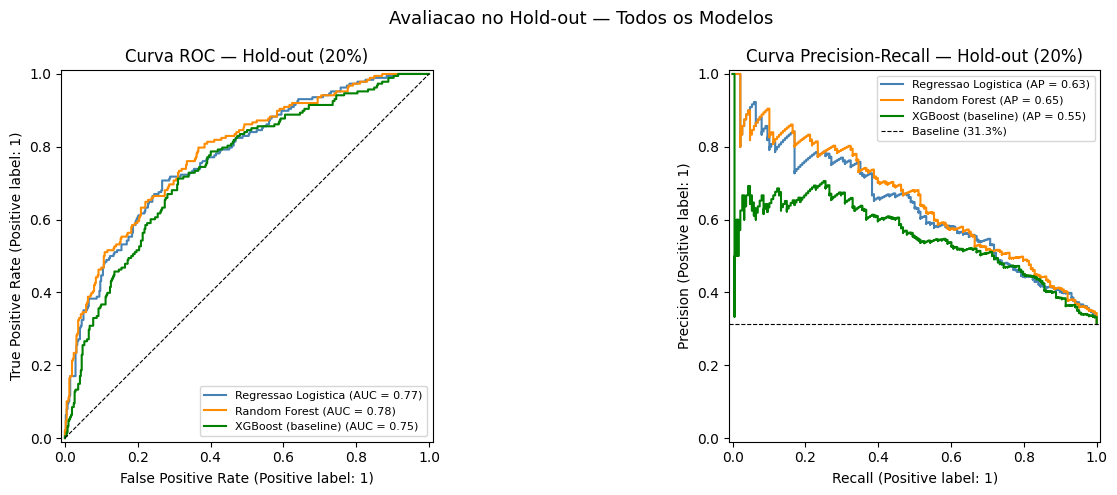

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cores = {
    "Regressao Logistica": "steelblue",
    "Random Forest"      : "darkorange",
    "XGBoost (baseline)" : "green",
}

# Curva ROC
for nome, modelo in modelos_tunados.items():
    RocCurveDisplay.from_estimator(
        modelo, X_test, y_test,
        ax=axes[0], name=nome, color=cores[nome]
    )
axes[0].plot([0, 1], [0, 1], "k--", linewidth=0.8)
axes[0].set_title("Curva ROC — Hold-out (20%)")
axes[0].legend(loc="lower right", fontsize=8)

# Curva Precision-Recall
for nome, modelo in modelos_tunados.items():
    PrecisionRecallDisplay.from_estimator(
        modelo, X_test, y_test,
        ax=axes[1], name=nome, color=cores[nome]
    )

# Baseline da curva PR = prevalencia do target
baseline_pr = y_test.mean()
axes[1].axhline(baseline_pr, color="black", linestyle="--",
                linewidth=0.8, label=f"Baseline ({baseline_pr:.1%})")
axes[1].set_title("Curva Precision-Recall — Hold-out (20%)")
axes[1].legend(loc="upper right", fontsize=8)

plt.suptitle("Avaliacao no Hold-out — Todos os Modelos", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import roc_curve

# Analise de threshold sobre o modelo final: Regressao Logistica
y_prob_lr = probs_ho["Regressao Logistica"]
fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)

# --- Abordagem 1: Distancia ao canto superior esquerdo da curva ROC ---
distancias = np.sqrt(fpr**2 + (tpr - 1)**2)
idx_dist   = np.argmin(distancias)
thr_dist   = thresholds[idx_dist]

# --- Abordagem 2: Custo de negocio ---
custo_fn = 5.0
custo_fp = 1.0

fnr       = 1 - tpr
custos    = (custo_fp * fpr) + (custo_fn * fnr)
idx_custo = np.argmin(custos)
thr_custo = thresholds[idx_custo]

print(f"Threshold padrao          : 0.5000")
print(f"Threshold distancia ROC   : {thr_dist:.4f}  | TPR={tpr[idx_dist]:.3f} | FPR={fpr[idx_dist]:.3f}")
print(f"Threshold custo negocio   : {thr_custo:.4f}  | TPR={tpr[idx_custo]:.3f} | FPR={fpr[idx_custo]:.3f}")

Threshold padrao          : 0.5000
Threshold distancia ROC   : 0.5149  | TPR=0.707 | FPR=0.267
Threshold custo negocio   : 0.1555  | TPR=0.989 | FPR=0.847


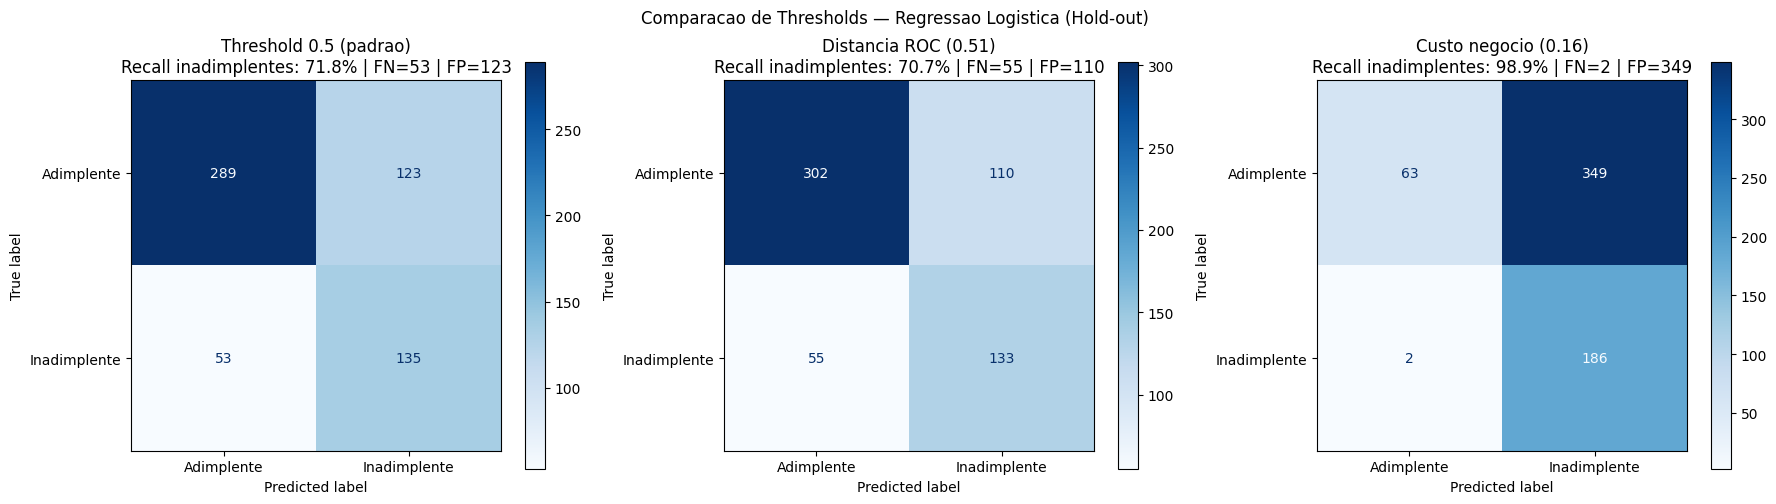

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

thresholds_analise = {
    "Threshold 0.5 (padrao)"      : 0.5,
    f"Distancia ROC ({thr_dist:.2f})"  : thr_dist,
    f"Custo negocio ({thr_custo:.2f})" : thr_custo,
}

for ax, (label, thr) in zip(axes, thresholds_analise.items()):
    y_pred = (y_prob_lr >= thr).astype(int)
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=["Adimplente", "Inadimplente"],
        cmap="Blues", ax=ax
    )
    fn = ((y_pred == 0) & (y_test == 1)).sum()
    fp = ((y_pred == 1) & (y_test == 0)).sum()
    tp = ((y_pred == 1) & (y_test == 1)).sum()
    recall = tp / (tp + fn)
    ax.set_title(f"{label}\nRecall inadimplentes: {recall:.1%} | FN={fn} | FP={fp}")

plt.suptitle("Comparacao de Thresholds — Regressao Logistica (Hold-out)", fontsize=12)
plt.tight_layout()
plt.show()

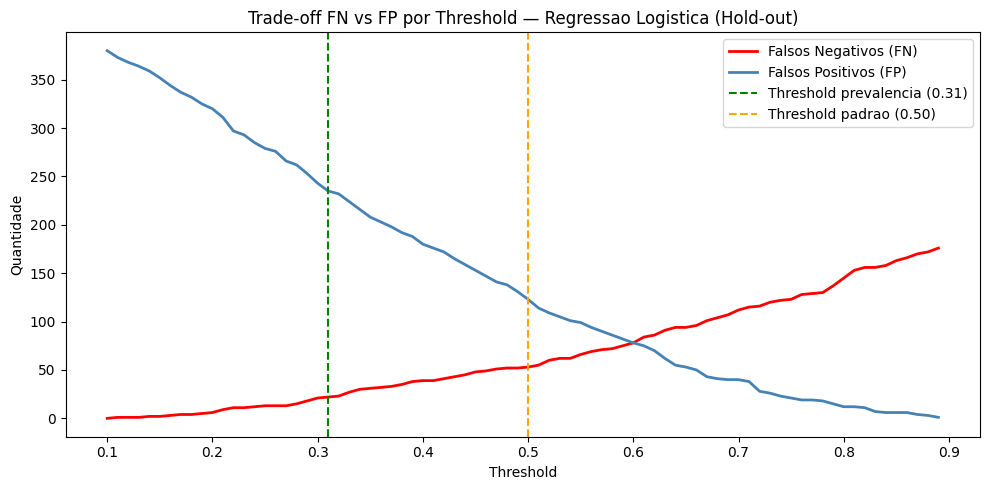

In [ ]:
thresholds_sweep = np.arange(0.1, 0.9, 0.01)

fns, fps, recalls, precisoes = [], [], [], []

for thr in thresholds_sweep:
    y_pred = (y_prob_lr >= thr).astype(int)
    fn = ((y_pred == 0) & (y_test == 1)).sum()
    fp = ((y_pred == 1) & (y_test == 0)).sum()
    tp = ((y_pred == 1) & (y_test == 1)).sum()
    fns.append(fn)
    fps.append(fp)
    recalls.append(tp / (tp + fn) if (tp + fn) > 0 else 0)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds_sweep, fns, label="Falsos Negativos (FN)", color="red",    linewidth=2)
ax.plot(thresholds_sweep, fps, label="Falsos Positivos (FP)", color="steelblue", linewidth=2)
ax.axvline(0.31, color="green",  linestyle="--", linewidth=1.5, label="Threshold prevalencia (0.31)")
ax.axvline(0.50, color="orange", linestyle="--", linewidth=1.5, label="Threshold padrao (0.50)")
ax.set_xlabel("Threshold")
ax.set_ylabel("Quantidade")
ax.set_title("Trade-off FN vs FP por Threshold — Regressao Logistica (Hold-out)")
ax.legend()
plt.tight_layout()
plt.show()

Taxa de inadimplencia por decil de score (decil 1 = menor risco, 10 = maior risco)
          Score Min  Score Max  Total  Inadimplentes  Taxa Inad.  % Inad. Acum.
Decil 1       0.007      0.148     60              2       0.033          0.011
Decil 2       0.149      0.216     60              7       0.117          0.048
Decil 3       0.216      0.292     60             10       0.167          0.101
Decil 4       0.292      0.358     60             13       0.217          0.170
Decil 5       0.358      0.442     60             13       0.217          0.239
Decil 6       0.443      0.515     60             13       0.217          0.309
Decil 7       0.517      0.609     60             26       0.433          0.447
Decil 8       0.610      0.693     60             24       0.400          0.574
Decil 9       0.694      0.794     60             33       0.550          0.750
Decil 10      0.795      0.965     60             47       0.783          1.000

Taxa global de inadimplencia no hold

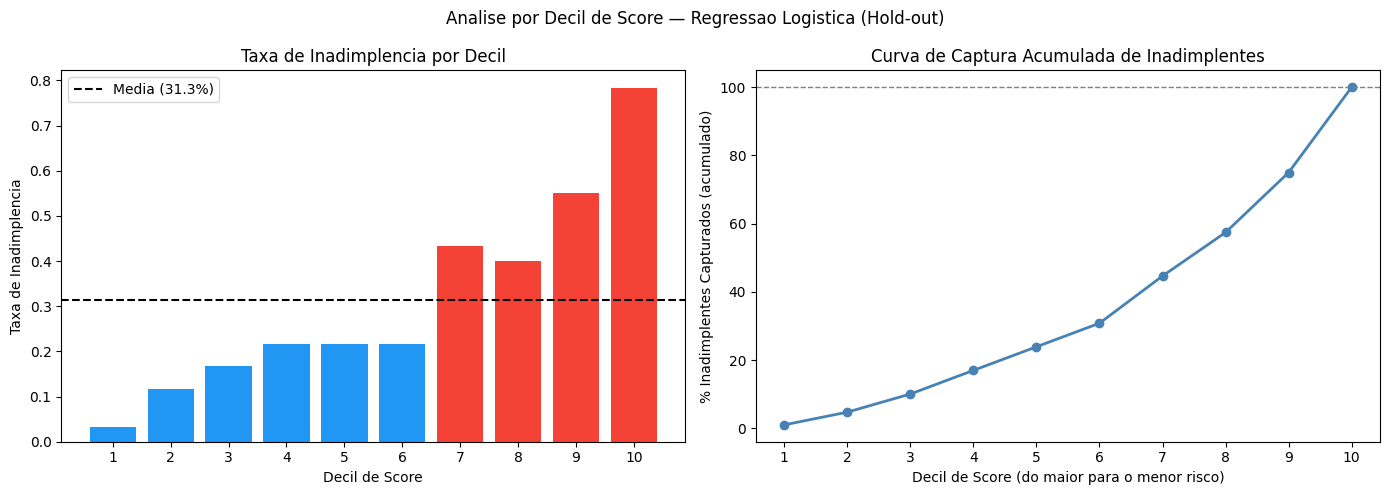

In [ ]:
# Analise por decil de score — como o modelo ordena os clientes por risco
# Cada decil contem ~10% dos clientes, ordenados do menor para o maior score

df_decil = pd.DataFrame({
    "real": y_test.values,
    "prob": y_prob_lr
})

df_decil["decil"] = pd.qcut(
    df_decil["prob"], q=10, labels=False, duplicates="drop"
)

relatorio = df_decil.groupby("decil").agg(
    score_min    = ("prob", "min"),
    score_max    = ("prob", "max"),
    total        = ("real", "count"),
    inadimplentes= ("real", "sum"),
).assign(
    taxa_inad    = lambda d: d["inadimplentes"] / d["total"],
    taxa_acum    = lambda d: d["inadimplentes"].cumsum() / d["inadimplentes"].sum(),
)

relatorio.index = [f"Decil {i+1}" for i in range(len(relatorio))]
relatorio.columns = ["Score Min", "Score Max", "Total", "Inadimplentes", "Taxa Inad.", "% Inad. Acum."]

print("Taxa de inadimplencia por decil de score (decil 1 = menor risco, 10 = maior risco)")
print("=" * 80)
print(relatorio.to_string(float_format="{:.3f}".format))
print()
print(f"Taxa global de inadimplencia no hold-out: {y_test.mean():.1%}")

# Visualizacao
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Taxa de inadimplencia por decil
axes[0].bar(range(1, len(relatorio) + 1),
            relatorio["Taxa Inad."],
            color=["#2196F3" if t < y_test.mean() else "#F44336"
                   for t in relatorio["Taxa Inad."]])
axes[0].axhline(y_test.mean(), color="black", linestyle="--",
                linewidth=1.5, label=f"Media ({y_test.mean():.1%})")
axes[0].set_xlabel("Decil de Score")
axes[0].set_ylabel("Taxa de Inadimplencia")
axes[0].set_title("Taxa de Inadimplencia por Decil")
axes[0].set_xticks(range(1, len(relatorio) + 1))
axes[0].legend()

# % acumulada de inadimplentes capturados
axes[1].plot(range(1, len(relatorio) + 1),
             relatorio["% Inad. Acum."] * 100,
             marker="o", color="steelblue", linewidth=2)
axes[1].axhline(100, color="gray", linestyle="--", linewidth=1)
axes[1].set_xlabel("Decil de Score (do maior para o menor risco)")
axes[1].set_ylabel("% Inadimplentes Capturados (acumulado)")
axes[1].set_title("Curva de Captura Acumulada de Inadimplentes")
axes[1].set_xticks(range(1, len(relatorio) + 1))

plt.suptitle("Analise por Decil de Score — Regressao Logistica (Hold-out)", fontsize=12)
plt.tight_layout()
plt.show()

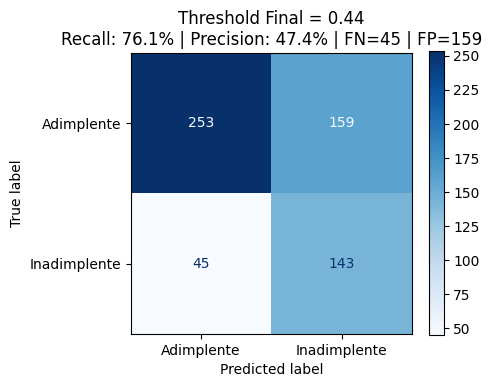

Threshold final     : 0.44
Inadimplentes capturados (Recall) : 76.1%  (143 de 188)
Falsos Negativos (prejuizo direto): 45
Falsos Positivos (oportunidade perdida): 159
Adimplentes aprovados corretamente: 253 de 412 (61.4%)


In [ ]:
# Threshold escolhido: 0.44 (inicio do Decil 7 — ponto de ruptura do risco)
# Justificativa: decis 1-6 ficam abaixo da media (<=21.7%); a partir do decil 7
# o risco dispara (43%+). Threshold emerge dos dados, nao de valor arbitrario.

thr_final = 0.44
y_pred_final = (y_prob_lr >= thr_final).astype(int)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_final,
    display_labels=["Adimplente", "Inadimplente"],
    cmap="Blues", ax=ax
)

tp = ((y_pred_final == 1) & (y_test == 1)).sum()
fn = ((y_pred_final == 0) & (y_test == 1)).sum()
fp = ((y_pred_final == 1) & (y_test == 0)).sum()
tn = ((y_pred_final == 0) & (y_test == 0)).sum()

recall    = tp / (tp + fn)
precision = tp / (tp + fp)

ax.set_title(f"Threshold Final = 0.44\nRecall: {recall:.1%} | Precision: {precision:.1%} | FN={fn} | FP={fp}")
plt.tight_layout()
plt.show()

print(f"Threshold final     : {thr_final}")
print(f"Inadimplentes capturados (Recall) : {recall:.1%}  ({tp} de {tp+fn})")
print(f"Falsos Negativos (prejuizo direto): {fn}")
print(f"Falsos Positivos (oportunidade perdida): {fp}")
print(f"Adimplentes aprovados corretamente: {tn} de {tn+fp} ({tn/(tn+fp):.1%})")

In [ ]:
import os

MODEL_PATH = "/content/drive/MyDrive/ML_Inadimplencia_Praso/models"
os.makedirs(MODEL_PATH, exist_ok=True)

# Pipeline completo: preprocessor + LogReg tunada (L1, C=0.368, balanced
joblib.dump(
    tunados["Regressao Logistica"].best_estimator_,
    f"{MODEL_PATH}/modelo_aplicacao_lr.joblib"
)

# Hold-out para reproducibilidade no notebook XAI
X_test.to_parquet(f"{MODEL_PATH}/aplicacao_X_test.parquet", index=False)
y_test.to_frame().to_parquet(f"{MODEL_PATH}/aplicacao_y_test.parquet", index=False)

# Threshold final escolhido — salvo como referencia
threshold_info = {"threshold": thr_final, "justificativa": "inicio do decil 7 (ruptura de risco)"}
import json
with open(f"{MODEL_PATH}/aplicacao_threshold.json", "w") as f:
    json.dump(threshold_info, f, indent=2)

print("Artefatos salvos:")
print(f"  modelo_aplicacao_lr.joblib")
print(f"  aplicacao_X_test.parquet   — {X_test.shape}")
print(f"  aplicacao_y_test.parquet   — {y_test.shape}")
print(f"  aplicacao_threshold.json   — threshold={thr_final}")

Artefatos salvos:
  modelo_aplicacao_lr.joblib
  aplicacao_X_test.parquet   — (600, 24)
  aplicacao_y_test.parquet   — (600,)
  aplicacao_threshold.json   — threshold=0.44
